In [360]:
# from data import hrrr_data, nam_data
import pandas as pd
import numpy as np
from datetime import timedelta
import os
import matplotlib.pyplot as plt
import gc
import matplotlib.dates as mdates
from datetime import datetime
import shutil
import statistics as st
from pathlib import Path
import re
import random
import traceback

In [361]:
def random_sampler(df, n):
    # Get the list of indices from the DataFrame
    i = df.index.tolist()

    # Randomly sample 20 values from the index list
    sampled_indices = random.sample(i, n)

    return sampled_indices

In [362]:
def refit(df):
    ruler = len(df)
    tithe = ruler * 0.1
    indexes = random_sampler(df, int(ruler))
    df = df.loc[indexes]

    targets = []
    lstms = []

    for i in indexes:
        print(df.columns)
        _, target, lstm_val = df.loc[i].values
        targets.append(target)
        lstms.append(lstm_val)

    mean1 = st.mean(targets)
    mean2 = st.mean(lstms)

    diff = mean2 - mean1

    df["Model forecast"] = df["Model forecast"] - diff

    return df, diff

In [363]:
def linear_fit(df, df_out, diff):
    df_out = df_out.copy()
    df = df.copy()
    # Assuming df is your DataFrame and 'column_name' is the column you're interested in
    length = len(df["target_error"].values)
    tener = int(length * 0.1)
    top_200_max_values = df["target_error"].nlargest(10)
    top_200_indexes = top_200_max_values.index

    alphas = []

    for i in top_200_indexes:
        (
            _,
            target,
            lstm_val,
        ) = df.loc[i].values
        alpha = abs(target / lstm_val)
        if alpha > 12:
            continue
        else:
            alphas.append(alpha)

    multiply = st.mean(alphas)

    df_out["Model forecast"] = df_out["Model forecast"] * multiply
    df_out = refit_output(df_out, diff)

    return df_out, multiply

In [364]:
def refit_output(df, diff):
    # Adjust the 'Model forecast' by subtracting the difference in means
    df["Model forecast"] = df["Model forecast"] - diff

    # Calculate the median of 'target_error_lead_0' and 'Model forecast'
    mean3 = st.median(df["target_error"])
    mean4 = st.median(df["Model forecast"])

    # Center both 'target_error_lead_0' and 'Model forecast' by subtracting their medians
    df["target_error"] = df["target_error"] - mean3
    df["Model forecast"] = df["Model forecast"] - mean4

    return df

In [365]:
def find_shift(ldf):
    """
    Determines the optimal shift for the "Model forecast" column in a DataFrame
    by minimizing the mean squared error (MSE) between the observed values
    and the shifted forecast values.

    Args:
        ldf (pd.DataFrame): A DataFrame containing at least two columns,
                            where the first column is the observed data
                            and the second column is "Model forecast".

    Returns:
        pd.DataFrame: The input DataFrame with the "Model forecast" column
                    shifted by the optimal lag value.
    """
    fh_s = []  # List to store shift values
    mean_s_ls = []  # List to store mean squared errors (MSE)
    mean_abs_ls = []  # List to store mean absolute errors (MAE)

    for i in np.arange(1, len(ldf)):  # Try shifts from 1 to 59
        df = ldf.copy()  # Create a copy to avoid modifying the original DataFrame

        # Shift the "Model forecast" column by i time steps, filling NaN values with 0
        df["Model forecast"] = df["Model forecast"].shift(i).fillna(0)

        # Compute the difference between the observed values and shifted forecast
        df["diff"] = df["target_error"] - df["Model forecast"]

        # Compute mean absolute error (MAE)
        mean = st.mean(abs(df["diff"]))

        # Compute mean squared error (MSE)
        mean_s = st.mean(df["diff"] ** 2)

        # Store results for each shift value
        fh_s.append(i)
        mean_s_ls.append(mean_s)
        mean_abs_ls.append(mean)

    # Create a DataFrame to store results
    results_df = pd.DataFrame(
        {"fh_s": fh_s, "mean_s_ls": mean_s_ls, "mean_abs_ls": mean_abs_ls}
    )

    # Get the shift value that results in the lowest mean squared error (MSE)
    best_fit = results_df.nsmallest(1, "mean_s_ls")
    shifter = best_fit["fh_s"].values[0]

    print("Shifting: ", shifter)  # Print the best shift value

    # Apply the optimal shift to the "Model forecast" column, filling NaNs with -999
    shifted = ldf["Model forecast"].shift(shifter).dropna().reset_index(drop=True)
    ldf = ldf.iloc[shifter:].reset_index(drop=True)  # Align ldf rows
    ldf["Model forecast"] = shifted
    if "Model variance" in ldf.columns:
        shifted2 = ldf["Model variance"].shift(shifter).dropna().reset_index(drop=True)
        ldf["Model variance"] = shifted2

    return ldf  # Return the modified DataFrame

In [366]:
def date_filter(ldf):
    time1 = datetime(2024, 1, 1, 0, 0, 0)
    time2 = datetime(2025, 12, 31, 23, 59, 59)
    ldf = ldf[ldf["valid_time"] > time1]
    ldf = ldf[ldf["valid_time"] < time2]

    return ldf

In [367]:
from sklearn.linear_model import LinearRegression


def linear_fit_data(df):
    # df_ = date_filter(df)
    x_col = df[["Model forecast"]]  # independent variable
    y_col = df["target_error"]  # dependent variable

    model = LinearRegression()
    model.fit(x_col, y_col)

    slope = model.coef_[0]
    intercept = model.intercept_

    # predict fitted y values based on x
    predicted_Y = model.predict(df[["Model forecast"]])

    # optionally, you can update the column in the dataframe:
    df["Model forecast"] = predicted_Y

    return df, slope, intercept

In [368]:
def linear_regression_refit(df, q, f):
    df_, _, _ = linear_fit_data(df)
    df_.to_parquet(f"{q}/refitted_{f}")

In [369]:
def main(directory, var, model_type):
    # load files to be calibrated
    stations = os.listdir(directory)

    for s in stations:
        q = f"{directory}/{s}"
        files = os.listdir(q)
        files = [f for f in files if model_type in f and var in f and "refit" not in f]

        for f in files:
            try:
                o = f"{q}/{f}"
                print(o)
                df = pd.read_parquet(o)

                # get_fh
                match = re.search(rf"_{var}_(\d+)_{model_type}_output\.parquet$", o)
                fh = int(match.group(1)) if match else None

                # shift dataframe from sequencer
                # df = find_shift(df)

                # fix unnormalize bugs
                df_calc, diff = refit(df)

                # target_outliers
                df_out_new_linear, multiply = linear_fit(df_calc, df, diff)

                # linear regression
                linear_regression_refit(df, q, f)
            except Exception as e:
                print(f"\n❌ ERROR processing file: {o}")
                print(f"Exception type: {type(e).__name__}")
                print(f"Message: {e}")
                traceback.print_exc()

In [370]:
main(
    "/home/aevans/nwp_bias/src/machine_learning/data/high_impact_weather_ouput/flash_flooding",
    "tp",
    "hybrid",
)

/home/aevans/nwp_bias/src/machine_learning/data/high_impact_weather_ouput/flash_flooding/STON/STON_tp_16_hybrid_output.parquet
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['v

Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^^^^^^^^^^
  File "/home/aevans/miniconda3/envs/metpy-ams-2023/lib/python3.11/statistics.py", line 432, in mean
    raise StatisticsError('mean requires at least one data point')
statistics.StatisticsError: mean requires at least one data point
Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^

Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='o

Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^^^^^^^^^^
  File "/home/aevans/miniconda3/envs/metpy-ams-2023/lib/python3.11/statistics.py", line 432, in mean
    raise StatisticsError('mean requires at least one data point')
statistics.StatisticsError: mean requires at least one data point
Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^

Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='o

...

Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^^^^^^^^^^
  File "/home/aevans/miniconda3/envs/metpy-ams-2023/lib/python3.11/statistics.py", line 432, in mean
    raise StatisticsError('mean requires at least one data point')
statistics.StatisticsError: mean requires at least one data point
Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^

/home/aevans/nwp_bias/src/machine_learning/data/high_impact_weather_ouput/flash_flooding/QUEE/QUEE_tp_17_hybrid_output.parquet
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['v

Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^^^^^^^^^^
  File "/home/aevans/miniconda3/envs/metpy-ams-2023/lib/python3.11/statistics.py", line 432, in mean
    raise StatisticsError('mean requires at least one data point')
statistics.StatisticsError: mean requires at least one data point
Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^

/home/aevans/nwp_bias/src/machine_learning/data/high_impact_weather_ouput/flash_flooding/QUEE/QUEE_tp_16_hybrid_output.parquet
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['valid_time', 'target_error', 'Model forecast'], dtype='object')
Index(['v

Traceback (most recent call last):
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/138513637.py", line 27, in main
    df_out_new_linear, multiply = linear_fit(df_calc, df, diff)
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/tmp.YGJG8VNvoz/ipykernel_1648146/2418443227.py", line 20, in linear_fit
    multiply = st.mean(alphas)
               ^^^^^^^^^^^^^^^
  File "/home/aevans/miniconda3/envs/metpy-ams-2023/lib/python3.11/statistics.py", line 432, in mean
    raise StatisticsError('mean requires at least one data point')
statistics.StatisticsError: mean requires at least one data point


In [371]:
df = pd.read_parquet(
    "/home/aevans/nwp_bias/src/machine_learning/data/high_impact_weather_ouput/flash_flooding/BKLN/refitted_BKLN_tp_18_hybrid_output.parquet"
)
df

,valid_time,target_error,Model forecast
0,2024-08-19 14:00:00,-0.424393,-0.449060
1,2024-08-19 15:00:00,-0.424393,-0.448715
2,2024-08-19 16:00:00,-0.424393,-0.450699
3,2024-08-19 17:00:00,-0.424393,-0.460601
4,2024-08-19 18:00:00,0.081483,-0.458831
5,2024-08-19 19:00:00,-0.424393,-0.463743
6,2024-08-19 20:00:00,-0.424393,-0.432179
7,2024-08-19 21:00:00,-0.424393,-0.448857
8,2024-08-19 22:00:00,-1.501668,-0.454253
9,2024-08-19 23:00:00,-0.122795,-0.446793


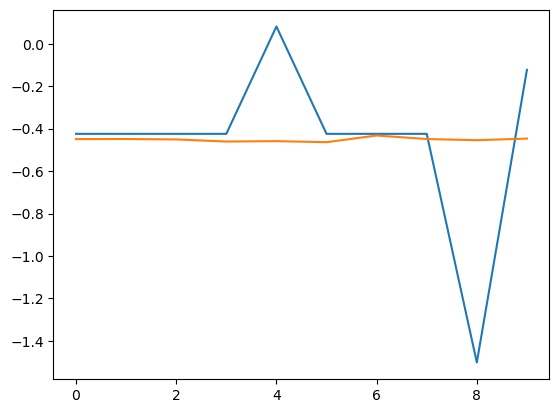

In [372]:
import matplotlib.pyplot as plt

plt.plot(df["target_error"])
plt.plot(df["Model forecast"])